# Equal Weighted Portfolio


## Imports

In [1]:
from trading_algos import datasets as tad
from trading_algos import optimization as tao
from trading_algos import utils as tau
from trading_algos import plots as tap

from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-05-14 21:04:37.837 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Data

In [2]:
# Selecting 5 stocks at random
tickers = tao.select_n(5,
                       tad.get_sp500_tickers(),
                       seed=42)
tickers

['UAL', 'NEM', 'COP', 'EVRG', 'ADBE']

In [3]:
# Load selecting stock data
df_stocks = tad.load_data(tickers=tickers,
                          start_date='2010-01-01',
                          end_date='2025-01-01')

[*********************100%***********************]  5 of 5 completed


In [4]:
df_stocks = df_stocks.dropna()
ht(df_stocks)

Price            Close                                              \
Ticker            ADBE        COP       EVRG        NEM        UAL   
Date                                                                 
2010-01-04   37.090000  22.623255  11.571108  34.152363  12.800000   
2010-01-05   37.700001  22.644773  11.417457  34.243999  13.910000   
2010-01-06   37.619999  22.808271  11.481032  34.970055  13.270000   
2024-12-27  446.480011  92.270203  58.852070  37.133987  99.650002   
2024-12-30  445.799988  92.432045  58.680378  36.309658  98.209999   
2024-12-31  444.679993  94.412262  58.708984  36.525555  97.099998   

Price             High                                               ...  \
Ticker            ADBE        COP       EVRG        NEM         UAL  ...   
Date                                                                 ...   
2010-01-04   37.299999  22.666282  11.661176  34.666939   13.110000  ...   
2010-01-05   37.799999  22.705010  11.613488  34.631693   14.100000  ...   
2010-01-06   37.740002  22.834087  11.481032  35.308406   13.990000  ...   
2024-12-27  449.910004  93.279353  59.166836  37.506898  100.550003  ...   
2024-12-30  447.600006  92.917579  58.852070  36.800329   98.970001  ...   
2024-12-31  448.500000  94.536030  59.090523  36.692381   98.250000  ...   

Price             Open                                                Volume  \
Ticker            ADBE        COP       EVRG        NEM         UAL     ADBE   
Date                                                                           
2010-01-04   36.650002  22.274743  11.613493  34.469568   12.990000  4710200   
2010-01-05   37.040001  22.653379  11.602891  34.173508   12.870000  7108800   
2010-01-06   37.330002  22.661983  11.396262  34.659897   13.740000  5336400   
2024-12-27  446.880005  92.346366  58.594532  36.908279  100.440002  2947200   
2024-12-30  442.940002  92.584372  58.804378  36.721820   98.309998  3473200   
2024-12-31  446.350006  92.631981  58.794830  36.309658   97.820000  2285100   

Price                                             
Ticker           COP     EVRG      NEM       UAL  
Date                                              
2010-01-04  13880848   597100  5625400   8785900  
2010-01-05  10084524   558600  7190500  23646300  
2010-01-06  11631913   491200  8018700  15398700  
2024-12-27   5889700   945300  5456100   3156900  
2024-12-30   5238800  3090200  7507800   3886400  
2024-12-31   5556400  1669800  9342600   2816800  

[6 rows x 25 columns]

In [5]:
df_stocks.isna().any().any()

np.False_

## Viz

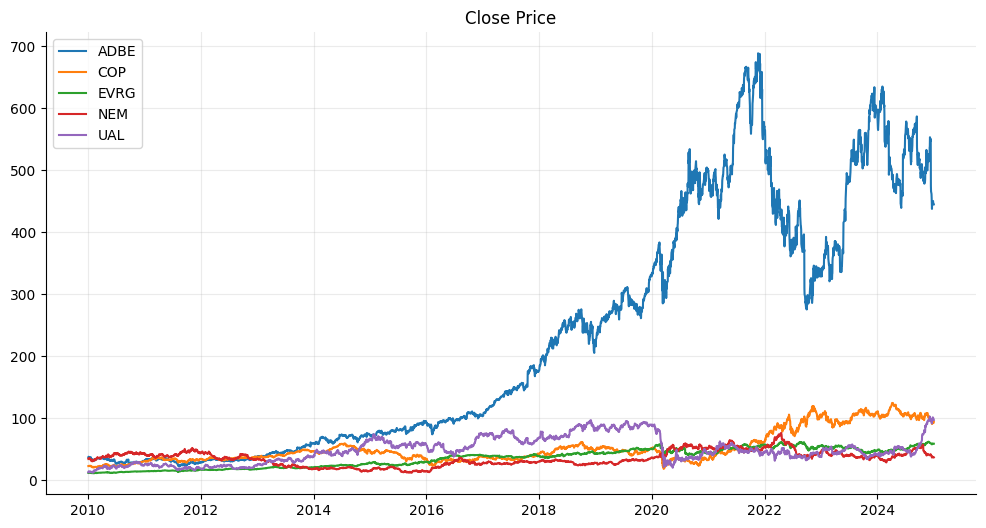

In [6]:
tap.trend(df_stocks);

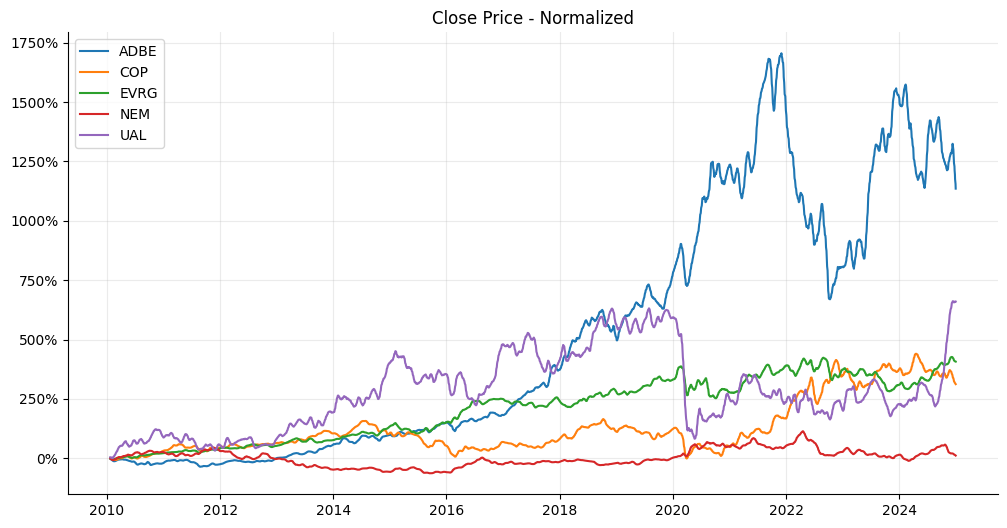

In [7]:
tap.trend(df_stocks, normalize=True, rolling=14);

## Creating the EWP

In [8]:
tao.calculate_weights(df_stocks, 'EWP')

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [9]:
ht(tau.calc_returns(df_stocks))

Ticker,ADBE,COP,EVRG,NEM,UAL
Date,,,,,
2010-01-05,0.016446,0.000951,-0.013279,0.002683,0.086719
2010-01-06,-0.002122,0.007220,0.005568,0.021202,-0.046010
2010-01-07,-0.019405,-0.003962,-0.006460,-0.006450,0.021100
2024-12-27,-0.008175,0.000310,0.000324,-0.006563,-0.012095
2024-12-30,-0.001523,0.001754,-0.002917,-0.022199,-0.014451
2024-12-31,-0.002512,0.021423,0.000487,0.005946,-0.011302


In [10]:
ht(tau.calc_returns(df_stocks).dot(tao.calculate_weights(df_stocks, 'EWP')))

Date
2010-01-05    0.018704
2010-01-06   -0.002828
2010-01-07   -0.003035
2024-12-27   -0.005240
2024-12-30   -0.007867
2024-12-31    0.002808
dtype: float64

In [11]:
df_returns = tao.portfolio_returns(df_stocks, 'EWP')
ht(df_returns)

Ticker,ADBE,COP,EVRG,NEM,UAL,EWP
Date,,,,,,
2010-01-05,0.016446,0.000951,-0.013279,0.002683,0.086719,0.018704
2010-01-06,-0.002122,0.007220,0.005568,0.021202,-0.046010,-0.002828
2010-01-07,-0.019405,-0.003962,-0.006460,-0.006450,0.021100,-0.003035
2024-12-27,-0.008175,0.000310,0.000324,-0.006563,-0.012095,-0.005240
2024-12-30,-0.001523,0.001754,-0.002917,-0.022199,-0.014451,-0.007867
2024-12-31,-0.002512,0.021423,0.000487,0.005946,-0.011302,0.002808


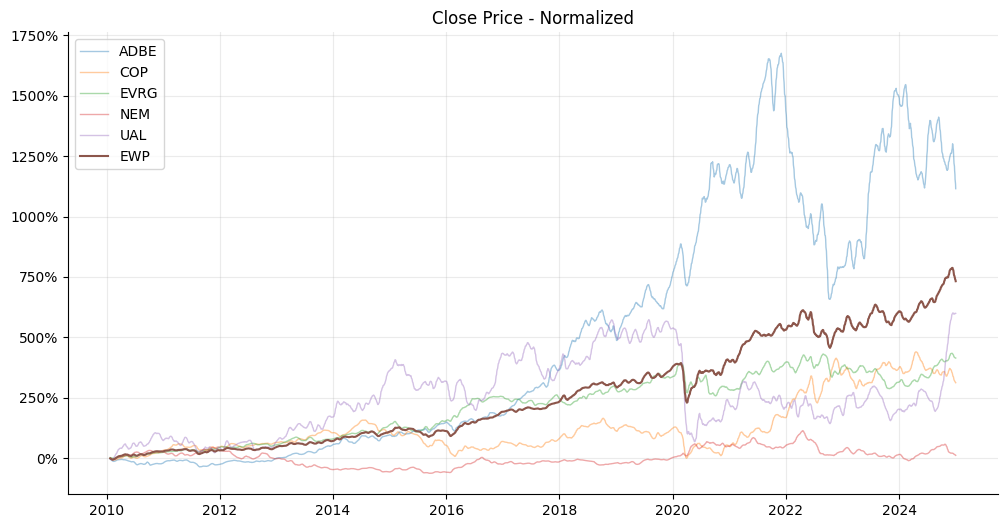

In [12]:
tap.trend(df_returns,
          returns=True,
          highlight=['EWP'],
          normalize=True,
          rolling=14);

## Calulate summary statistics on returns and portfolio returns

In [13]:
df_summary = tau.get_returns_summary(df_returns, annualize=True)
df_summary

,Return,Risk,Sharpe
Ticker,,,
ADBE,0.217661,0.320679,0.678750
COP,0.152431,0.337198,0.452053
EVRG,0.130516,0.209434,0.623183
NEM,0.066810,0.352887,0.189323
UAL,0.251613,0.481642,0.522405
EWP,0.163806,0.208270,0.786509


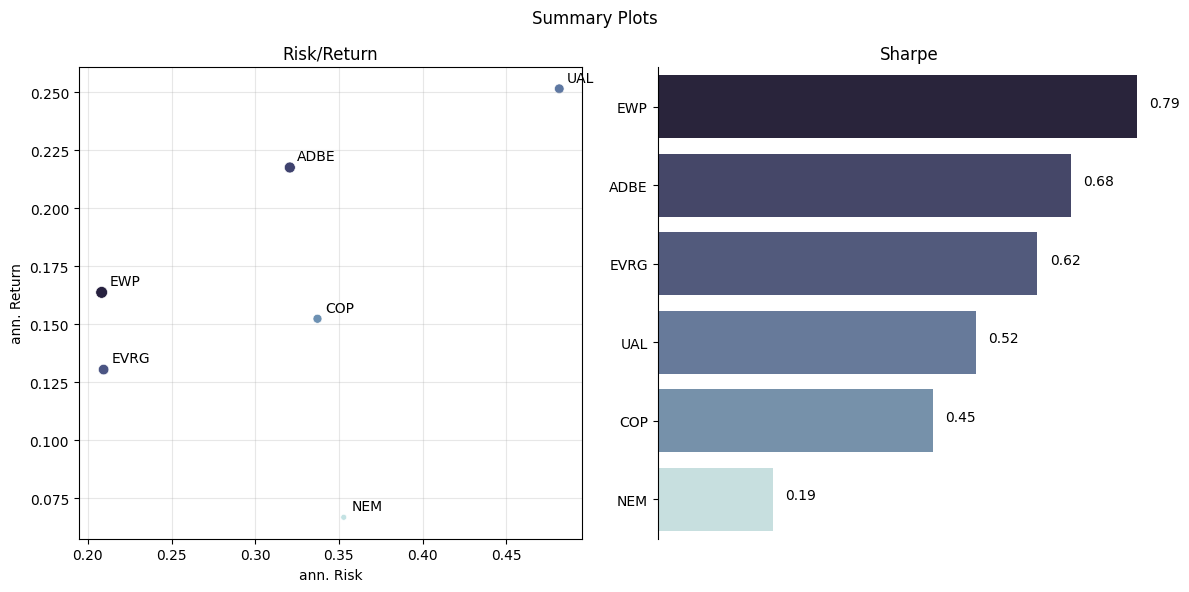

In [14]:
tap.plot_summary(df_summary);